In [1]:
import ROOT
import emm

import numpy as np
import matplotlib.pyplot as plt

Welcome to JupyROOT 6.30/04


In [2]:
# Get data
data_tree = emm.get_data(sort_and_index=True, tree=True)

x = ROOT.RooRealVar("x", "Diphoton Mass [GeV]", 500, 4000)
index=ROOT.RooRealVar("index", "index", 0, 0, 1e6)

data = ROOT.RooDataSet("mgg", "mgg", ROOT.RooArgSet(x, index), ROOT.RooFit.Import(data_tree))

Loaded 5036 diphoton invariant masses from data.


# Background Flexibility Proof of Concept

In [3]:
# Add signal to tail
n = 1

data_sig = data.Clone()
vals_to_add = np.random.normal(3800, 30, size=n)
for val in vals_to_add:
    x.setVal(val)
    index.setVal(data_sig.numEntries())
    data_sig.add(ROOT.RooArgSet(x, index))

print(f"Data entries (with tail events): {data_sig.numEntries()}")

Data entries (with tail events): 5037


[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_2_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
Minuit2Minimizer: Minimize with max-calls 1500 convergence for edm < 1 strategy 1
Minuit2Minimizer : Valid minimum - status = 0
FVAL  = 31049.2927446700924
Edm   = 0.000258102024069608845
Nfcn  = 96
raw_rate_0	  = 0.61455	 +/-  0.0470721	(limited)
raw_rate_1	  = 1.49227	 +/-  0.101585	(limited)
raw_weight_1	  = 0.643743	 +/-  0.313388
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_3_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
Minuit2Minimizer: Minimize with max-calls 2500 convergence for edm < 1 

Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =       31237.32818 Edm =       457.8392935 NCalls =     13
Info in <Minuit2>: MnSeedGenerator Initial state  
  Minimum value : 31237.32818
  Edm           : 457.8392935
  Internal parameters:	[     -1.370461484     -1.287002218                0]	
  Internal gradient  :	[      9914.588117      2303.839935      196.4485524]	
  Internal covariance matrix:
[[  7.6514145e-06              0              0]
 [              0  0.00012079111              0]
 [              0              0    0.011352342]]]
Info in <Minuit2>: VariableMetricBuilder Start iterating until Edm is < 0.001 with call limit = 1500
Info in <Minuit2>: VariableMetricBuilder    0 - FCN =       31237.32818 Edm =       457.8392935 NCalls =     13
Info in <Minuit2>: VariableMetricBuilder    1 - FCN =       31086.85054 Edm =        22.4823384 NCalls =     25
Info in <Minuit2>: VariableMet

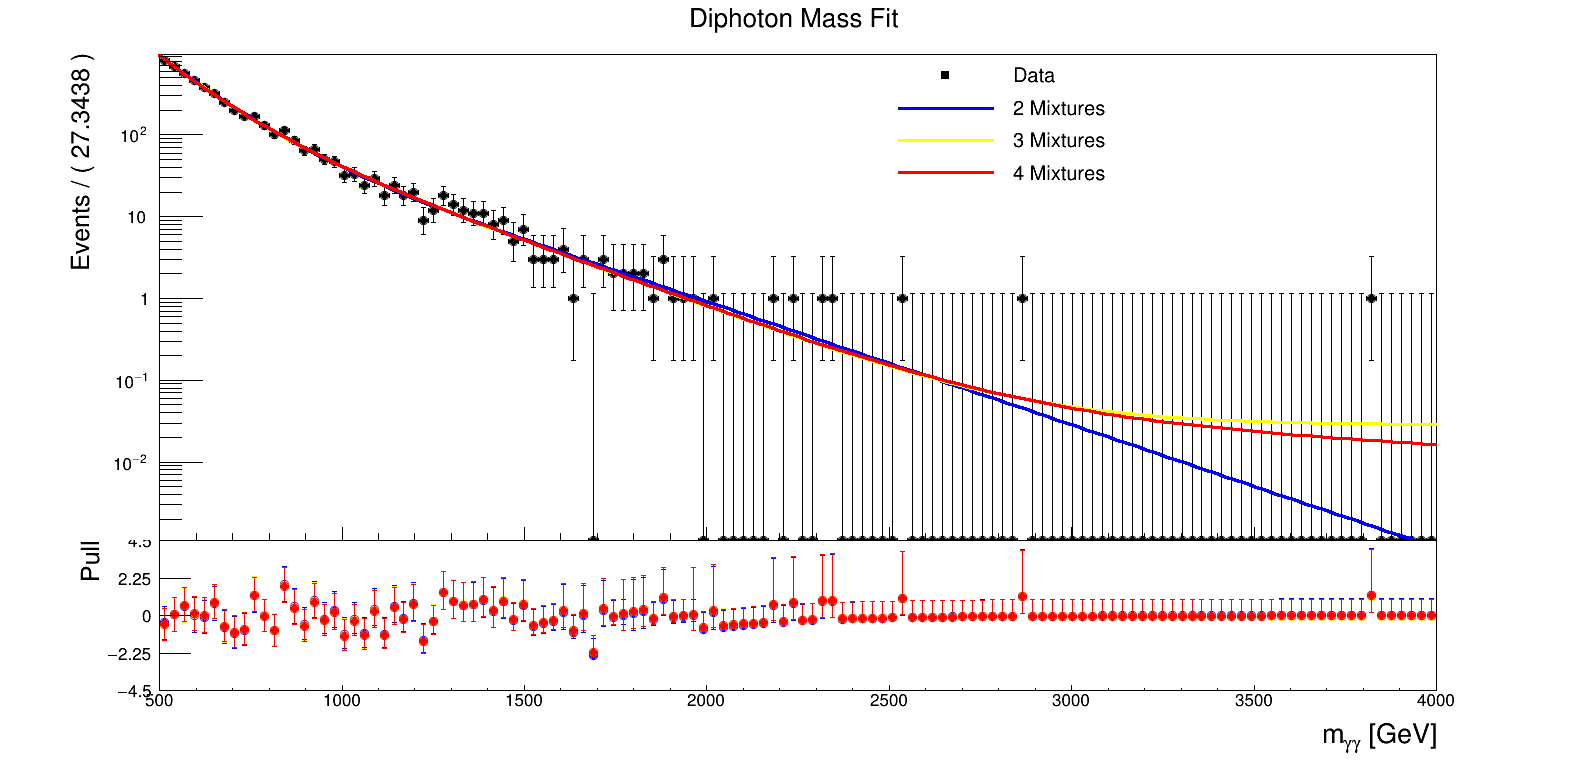

In [5]:
# Plot fits of varying complexity to the signal + background data
models = [emm.ExponentialMixtureModel(x, k, data_mean=data_sig.mean(x)) for k in range(2, 5)]
model_labels = [f"{k} Mixtures" for k in range(2, 5)]
fit_results = [m.pdf.fitTo(data_sig, ROOT.RooFit.Save()) for m in models]
emm.plot_fits(data_sig, x, models, model_labels, fit_results,)

# Signal Strength (with Combine)

In [50]:
pset = {
    # 'raw_rate_0': (0.3, 2.5, 20),
    # 'raw_rate_1': (0.3, 2.5, 20),
    "signal_strength": (0, 1000, 20),
}

def model_primitive(x, data):
    bkg_model = emm.ExponentialMixtureModel(x, 3, data_mean=data.mean(x), ordered_weights=True)
    # bkg_model.raw_rates[0].setVal(0.64)
    # bkg_model.raw_rates[1].setVal(1.45)
    # bkg_model.raw_rates[2].setVal(1.55)

    # bkg_model.pdf.fitTo(data, PrintLevel=-1)
    # bkg_model.raw_rates[0].setRange(0.4, 0.7)
    # bkg_model.raw_rates[1].setRange(1.2, 1.8)
    # return bkg_model
    signal_model = emm.GaussianSignalModel(x, 1200)
    model = emm.SignalPlusBackgroundModel(signal_model, bkg_model)
    return model

df = emm.profile_model(x, model_primitive, data, pset)
# fig, axes = emm.plot_pair_profiles(df, pset)

[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_Int[x]) using numeric integrator

Warning in <TBufferFile::WriteObjectAny>: since RooNLLVar has no public constructor
	which can be called without argument, objects of this class
	can not be read with the current library. You will need to
	add a default constructor before attempting to read it.
Warning in <TBufferFile::WriteObjectAny>: since RooNLLVar has no public constructor
	which can be called without argument, objects of this class
	can not be read with the current library. You will need to
	add a default constructor before attempting to read it.
Warning in <TBufferFile::WriteObjectAny>: since RooNLLVar has no public constructor
	which can be called without argument, objects of this class
	can not be read with the current library. You will need to
	add a default constructor before attempting to read it.
Warning in <TBufferFile::WriteObjectAny>: since RooNLLVar has no public constructor
	which can be called without argument, objects of this class
	can not be read with the current library. You will need to
	add a de

Fitted in 0.82 seconds
Fit status: -1, covQual: 0
NLL: 31030.826989510177


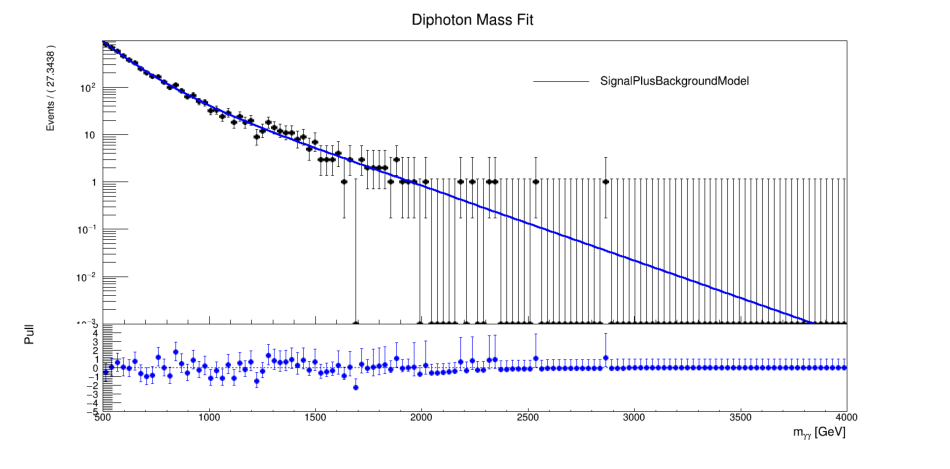

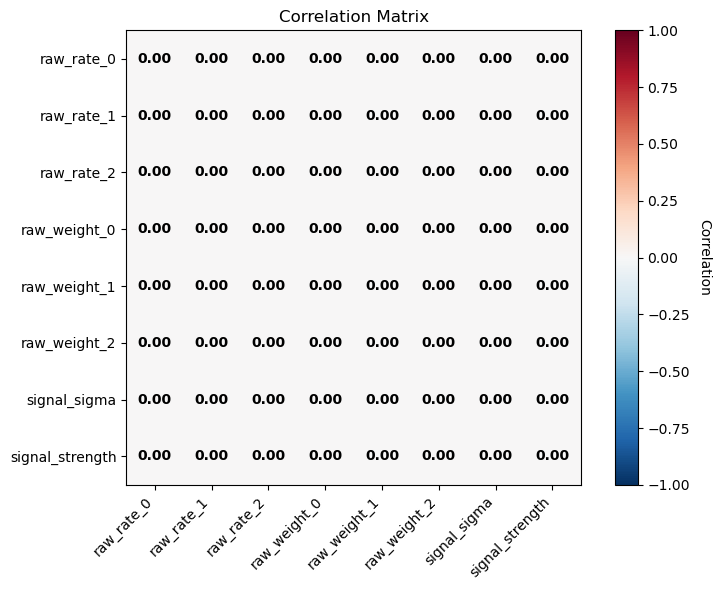

Model: SignalPlusBackgroundModel
signal_strength: 1.0000000000000002 + 0.0 -0.0
signal_mean: 1200.0
signal_sigma: 10.0 + 0.0 -0.0
raw_rate_0: 0.9373066669846405 + 0.0 -0.0
raw_rate_1: 0.6427646815888942 + 0.0 -0.0
raw_rate_2: 1.5371139477227995 + 0.0 -0.0
raw_weight_0: 0.003735592051041271 + 0.0 -0.0
raw_weight_1: 0.9675595595015115 + 0.0 -0.0
raw_weight_2: 0.5728141743664792 + 0.0 -0.0
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
Minuit2Minimizer: Minimize with max-calls 4000 convergence for edm < 1 strategy 1
Minuit2Minimizer : Valid minimum - status = 0
FVAL  = 31030.923414988687
Edm   = 0.000112792105676760081
Nfcn  = 206
raw_rate_0	  = 1.01152	 +/-  0.178761	(limited)
raw_rate_1	  = 0.619037	 +/-  0.0341937	(limited)
raw_rate_2	  = 1.60606	 +/-  0.113664	(limited)
raw_weight_0	  = 0.615168	 +/-  0.0611447	(limited)
raw_weight_1	  = 0.620501	 +/-  0.137027	(limited)
raw_weight

Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =       32079.64687 Edm =      -1300.864684 NCalls =     31
Info in <Minuit2>: NegativeG2LineSearch Doing a NegativeG2LineSearch since one of the G2 component is negative
Info in <Minuit2>: MnSeedGenerator Negative G2 found - new state: 
  Minimum value : 31190.21454
  Edm           : 756.0199172
  Internal parameters:	[     -1.370461484     -1.410418662     -1.222630306                0                0                0    -0.6475151779     -0.927295218]	
  Internal gradient  :	[       1065.00038      1189.339144      2890.106245     -85.89618532     -11.36552945      97.23180551                0                0]	
  Internal covariance matrix:
[[  8.9063448e-05              0              0              0              0              0              0              0]
 [              0  8.6217772e-06              0              0              0      

In [48]:
model = model_primitive(x, data)
# model = emm.ExponentialMixtureModel(x, 3, data_mean=data.mean(x),)
# model.raw_rates[0].setVal(0.5)
# model.raw_rates[1].setVal(1.5)
emm.fit_and_plot(model, data, x)

In [37]:
print(min(df['nll']))
print(max(df['nll']))


31030.923414988687
31030.923414988687


In [45]:
df

,signal_strength,nll
0,0.000,31030.827448
1,0.526,31030.923415
2,1.053,31030.827448
3,1.579,31030.923415
4,2.105,31030.827448
5,2.632,31030.923415
6,3.158,31030.827448
7,3.684,31030.923415
8,4.211,31030.827448
9,4.737,31030.923415


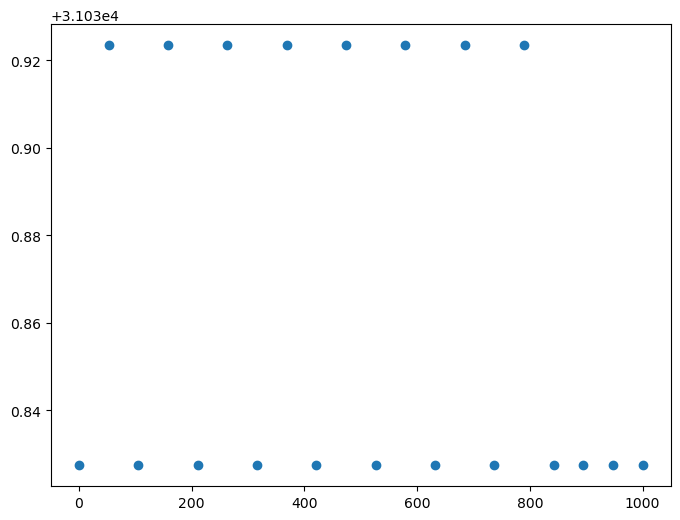

In [51]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(df['signal_strength'], df['nll'], marker='o', linestyle='none')

In [52]:
# With ROOT
model = model_primitive(x, data)
w = ROOT.RooWorkspace("w")
modelConfig = ROOT.RooStats.ModelConfig(w)
modelConfig.SetPdf(model.pdf)
modelConfig.SetParametersOfInterest(ROOT.RooArgSet(model.signal_strength))

In [53]:
plCalc = ROOT.RooStats.ProfileLikelihoodCalculator(data, modelConfig)
plCalc.SetConfidenceLevel(0.95)

In [54]:
interval = plCalc.GetInterval()

[#1] INFO:InputArguments -- The deprecated RooFit::CloneData(1) option passed to createNLL() is ignored.
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#0] PROGRESS:Minimization -- ProfileLikelihoodCalcultor::DoGLobalFit - find MLE 
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (signal_pdf,ExponentialMixtureModel)
[#0] PROGRESS:Minimization -- ProfileLikelihoodCalcultor::DoMinimizeNLL - using Minuit2 / Migrad with strategy 1
    ----> Doing a re-scan first
    ----> Doing a re-scan first
    ----> trying with improve
[#1] INFO:Minimization -- 
  RooFitResult: minimized FCN value: 31030.8, es

In [55]:
poi = modelConfig.GetParametersOfInterest()[0]
lower = interval.LowerLimit(poi)
upper = interval.UpperLimit(poi)
print(f"95% CL interval for signal fraction: [{lower}, {upper}]")

95% CL interval for signal fraction: [0.0, 10.0]
Error: Minimization failed  
Error returned from minimization of likelihood function - cannot find interval limits 


Error in <Minuit2>: Minuit2Minimizer::GetMinosError Failed - invalid function minimum


In [ ]:
plot = ROOT.RooStats.LikelihoodIntervalPlot(interval)
plot.SetNPoints(50)

c = ROOT.TCanvas("c", "Profile Likelihood Interval", 800, 600)
plot.Draw()
c.SaveAs("profile_likelihood_interval.png")



.
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooProfileLL::evaluate(nll_signal_plus_background_pdf_mgg_Profile[signal_fraction]) Creating instance of MINUIT
[#1] INFO:Minimization -- RooProfileLL::evaluate(nll_signal_plus_background_pdf_mgg_Profile[signal_fraction]) determining minimum likelihood for current configurations w.r.t all observable
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#0] ERROR:InputArguments -- RooArgSet::checkForDup: ERROR argument with name signal_fraction is already in this set
[#1] INFO:Minimization -- RooProfileLL::evaluate(nll_signal_plus_background_pdf_mgg_Profile[signal_fraction]) minimum found at (signal_fraction=0.000122022)
.............................................................................................

In [28]:
ROOT.gPad.Update()
ROOT.gPad.Draw()